## Problem Set 3
PHYSGR5084 Quantum Simulation and Computing Lab

Daniel Vitenko

In [5]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFTGate
import matplotlib.pyplot as plt
import numpy as np
from qiskit_aer import AerSimulator

%matplotlib inline

## (1b)

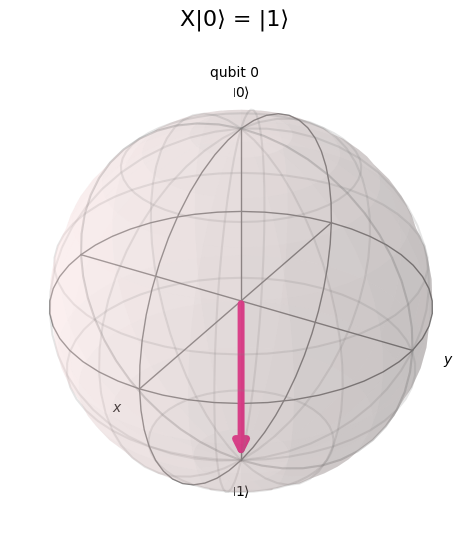

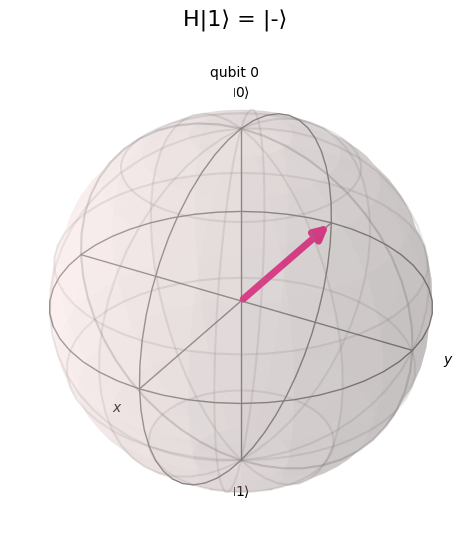

In [3]:
# i
qc = QuantumCircuit(1)
qc.x(0)
plot_bloch_multivector(Statevector(qc), title="X|0⟩ = |1⟩")

qc.h(0)
plot_bloch_multivector(Statevector(qc), title="H|1⟩ = |-⟩")

plt.show()

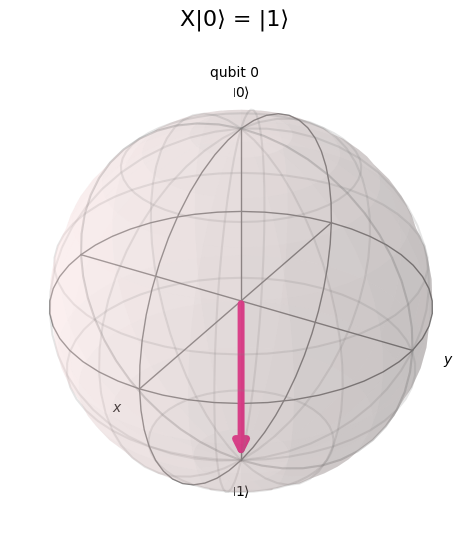

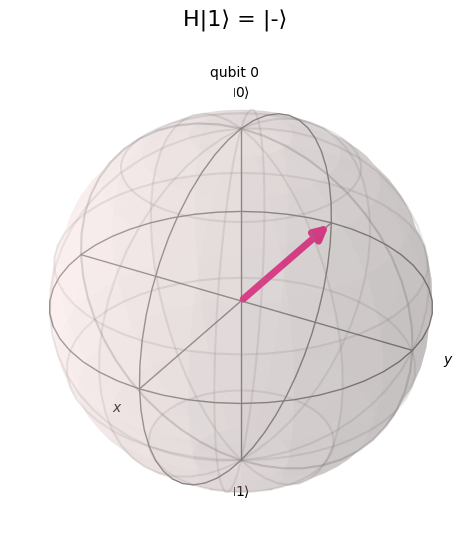

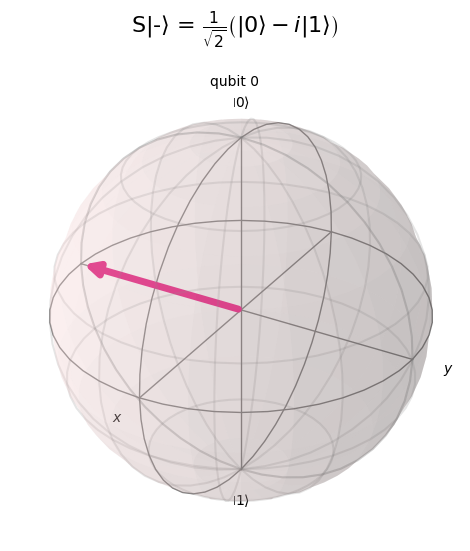

In [5]:
# ii
qc = QuantumCircuit(1)
qc.x(0)
plot_bloch_multivector(Statevector(qc), title="X|0⟩ = |1⟩")

qc.h(0)
plot_bloch_multivector(Statevector(qc), title="H|1⟩ = |-⟩")

qc.s(0)
plot_bloch_multivector(Statevector(qc), title=r"S|-⟩ = $\frac{1}{\sqrt{2}}\left(|0\rangle - i|1\rangle\right)$")

plt.show()

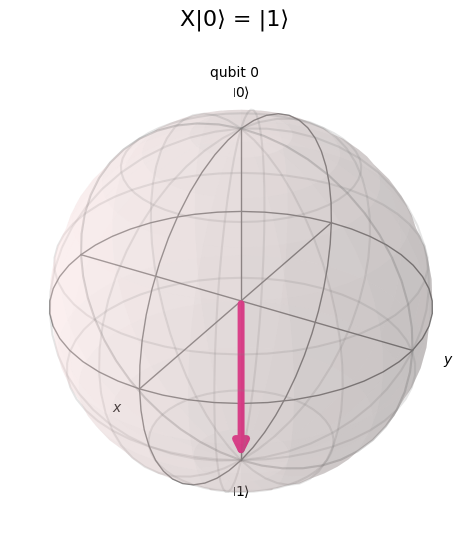

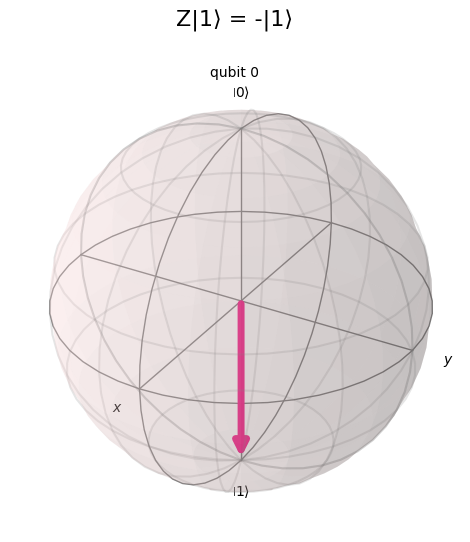

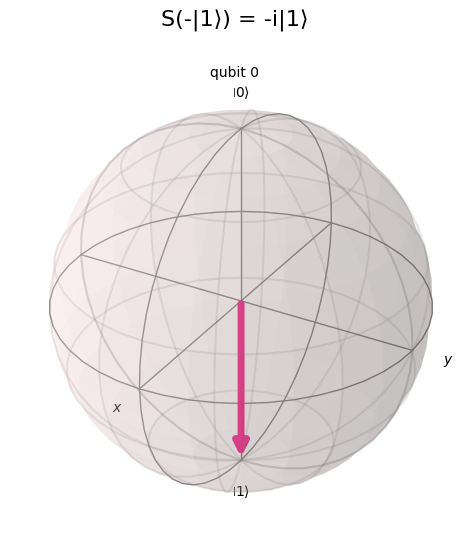

In [7]:
# iii
qc = QuantumCircuit(1)
qc.x(0)
plot_bloch_multivector(Statevector(qc), title="X|0⟩ = |1⟩")

qc.z(0)
plot_bloch_multivector(Statevector(qc), title="Z|1⟩ = -|1⟩")

qc.s(0)
plot_bloch_multivector(Statevector(qc), title="S(-|1⟩) = -i|1⟩")

plt.show()

# 2

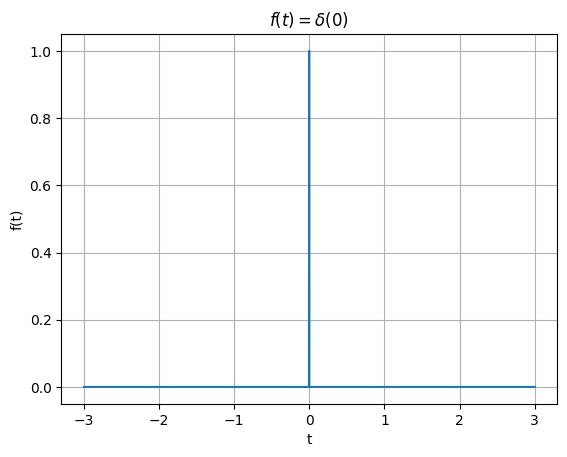

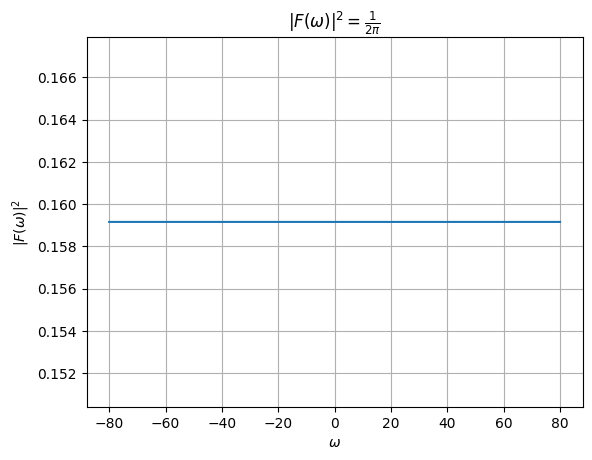

In [17]:
#i
w0 = 2 * np.pi * 5 
sigma = 1.0 

t = np.linspace(-3, 3, 2000)
w = np.linspace(-80, 80, 4000)

# cannot plot true delta function  
f_a = np.zeros_like(t)
f_a[np.argmin(abs(t))] = 1

F_a = np.ones_like(w) / (2 * np.pi)

plt.plot(t, f_a)
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title(r"$f(t)=\delta(0)$")
plt.grid(True)
plt.show()

plt.plot(w, F_a)
plt.xlabel(r"$\omega$")
plt.ylabel(r"$|F(\omega)|^2$")
plt.title(r"$|F(\omega)|^2 = \frac{1}{2\pi}$")
plt.grid(True)
plt.show()

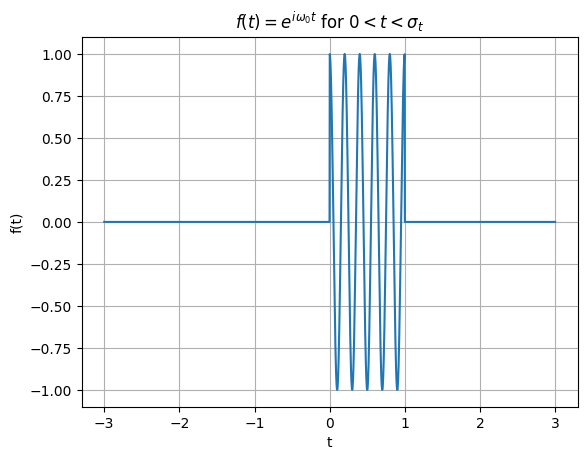

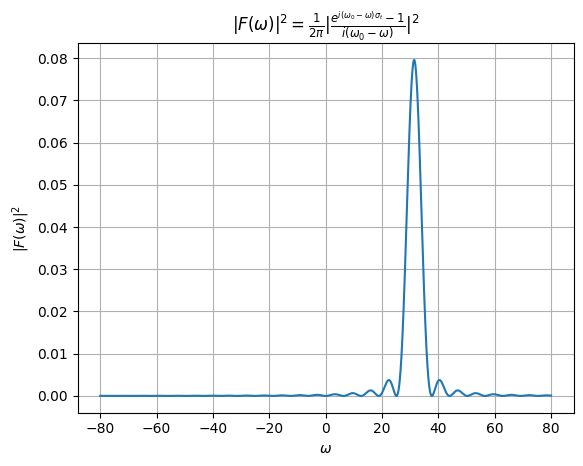

In [34]:
#ii

f_b = np.where((t > 0) & (t < sigma), np.exp(1j*w0*t), 0)

F_b = (1/(2*np.pi)) * (np.exp(1j * (w0-w) * sigma)-1)/(1j * (w0-w))**2

plt.plot(t, f_b)
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title(r"$f(t)=e^{i\omega_0 t}$ for $0<t<\sigma_t$")
plt.grid(True)
plt.show()

plt.plot(w, F_b)
plt.xlabel(r"$\omega$")
plt.ylabel(r"$|F(\omega)|^2$")
plt.title(r"$|F(\omega)|^2 = \frac{1}{2\pi}|\frac{e^{i(\omega_0-\omega)\sigma_t}-1}{i(\omega_0-\omega)}|^2$")
plt.grid(True)
plt.show()

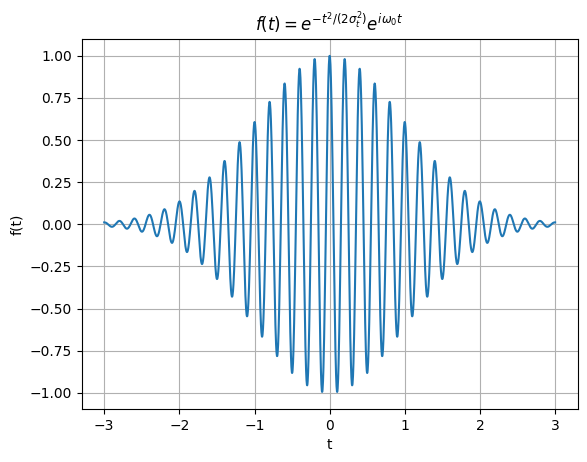

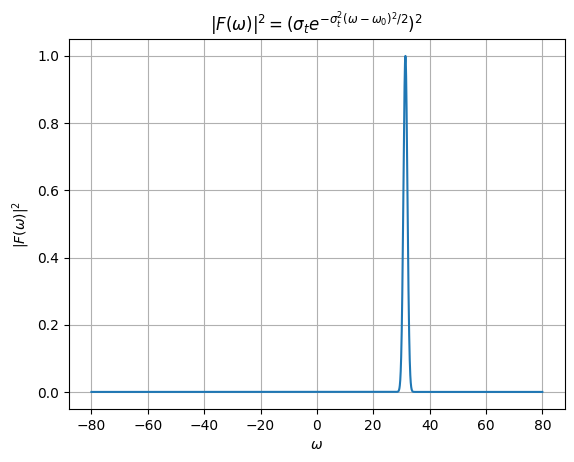

In [42]:
#iii

f_c = np.exp(-t**2 / (2 * sigma**2)) * np.exp(1j * w0 * t)

F_c = (sigma * np.exp(-sigma**2 * (w - w0)**2 / 2))**2

plt.plot(t, f_c)
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title(r"$f(t)=e^{-t^2/(2\sigma_t^2)}e^{i\omega_0 t}$")
plt.grid(True)
plt.show()

plt.plot(w, F_c)
plt.xlabel(r"$\omega$")
plt.ylabel(r"$|F(\omega)|^2$")
plt.title(r"$|F(\omega)|^2 = (\sigma_t e^{-\sigma_t^2 (\omega - \omega_0)^2 / 2})^2$")
plt.grid(True)
plt.show()

# 3b

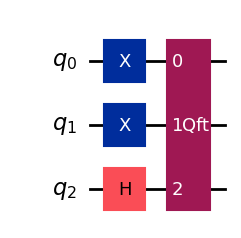

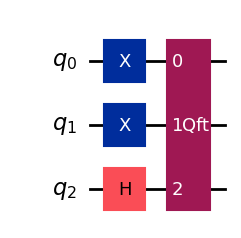

In [47]:
qc = QuantumCircuit(3)

# prepare state
qc.x(0)
qc.x(1)
qc.h(2)

qc.append(QFTGate(3), qc.qubits)

qc.draw("mpl")


# 4b

In [16]:
def F(qc):
    # define the Quantum Fourier Transform
    qc.h(0)
    qc.cp(np.pi/2, 1, 0)
    qc.h(1)
    qc.swap(0, 1)
    qc.barrier()
    return qc

def F_inv(qc):
    # define the Inverse Quantum Fourier Transform
    qc.swap(0, 1)
    qc.h(1)
    qc.cp(-np.pi/2, 0, 1)
    qc.h(0)
    qc.barrier()
    return qc  

# Defining the diagonal e^{-iKt} matrix
def D(qc, theta0, theta1, theta2):
    qc.rz(theta0, 0)
    qc.rz(theta1, 1)
    qc.cp(theta2, 1, 0)
    return qc

def V(qc, a, b, v_0, delta_t):
    qc.rz(b * v_0 * delta_t, 0)
    qc.rz(a * v_0 * delta_t, 1)
    qc.cp(-b * v_0 * delta_t, 1, 0)
    qc.barrier()
    return qc

def apply_evo(qc, a, b, v_0, delta_t, theta0, theta1, theta2):
    F(qc)
    D(qc, theta0, theta1, theta2)
    F_inv(qc)
    V(qc, a, b, v_0, delta_t)
    qc.barrier()
    return qc

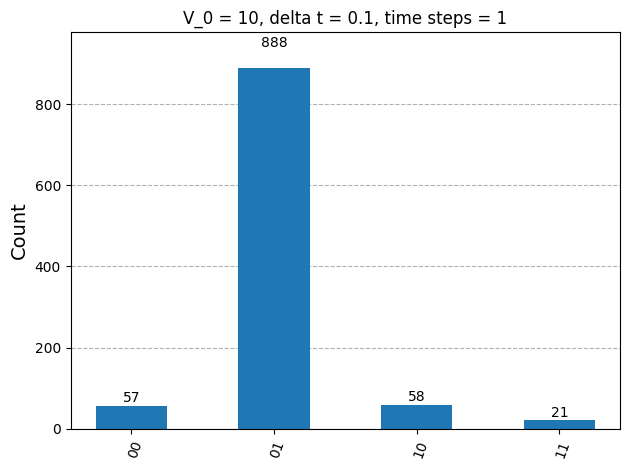

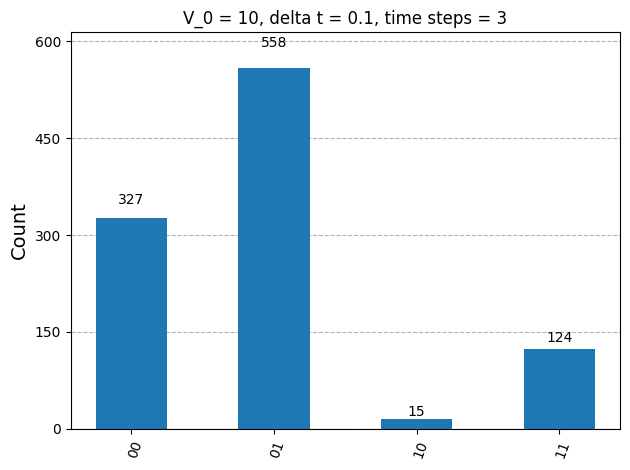

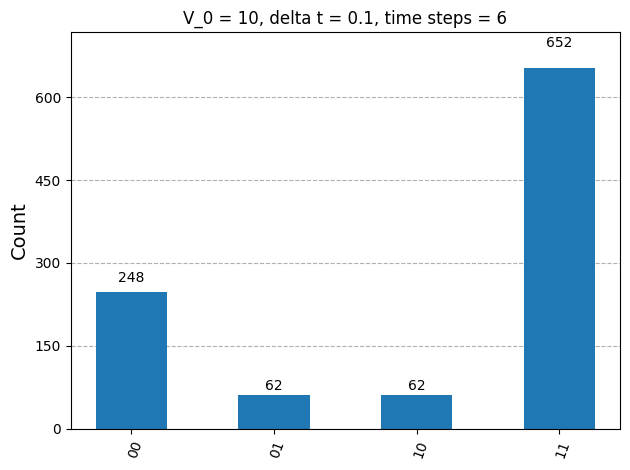

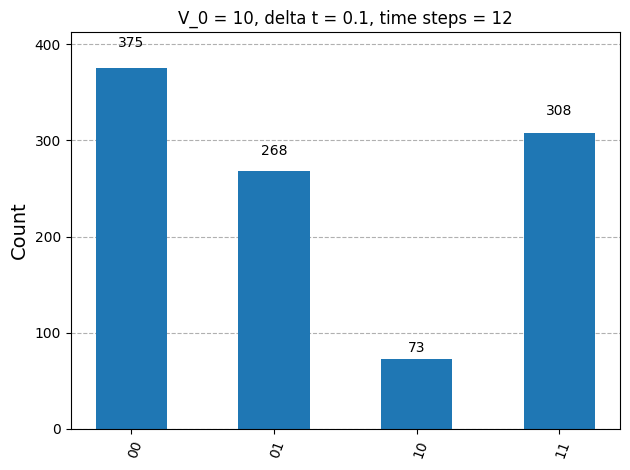

In [27]:
def get_circuit_simulation(time_steps, a, b, v_0, delta_t, theta0, theta1, theta2):
    qc = QuantumCircuit(2, 2)
    
    # Create the initial state. We start in |01>
    qc.x(1)
    qc.barrier()

    i = 0
    while i < time_steps:
        apply_evo(qc, a, b, v_0, delta_t, theta0, theta1, theta2) 
        i+=1

    qc.swap(0,1)
    
    qc.measure([0,1], [0,1])
    
    return(qc)

delta_t = 1 / 10
theta0 = -np.pi*np.pi*delta_t
theta1 = -np.pi*np.pi*delta_t/4
theta2 = np.pi*np.pi*delta_t
v_0 = 10
a = 50
b = 48

time_steps = [1,3,6,12]
for t in time_steps:
#print(qc2.draw('mpl'))
    qc2 = get_circuit_simulation(t, a, b, v_0, delta_t, theta0, theta1, theta2)

    result = AerSimulator().run(qc2).result()
    # collect stats
    statistics = result.get_counts()

    plot_histogram(statistics, title = "V_0 = " + str(v_0) + ", delta t = " + str(delta_t) + ", time steps = " + str(t));